# 05 · One program, many machines

The flux sweep from Part 3 works. It found the sweet spot, and the numbers agreed with the device.
Now someone in the lab next door wants to run it on their rack, and their rack is not your rack.

This part is about the seam between a program and a machine:

- **5.1** What has to be checked before a program reaches an instrument.
- **5.2** Capability tokens, limits, and predicates: how a platform states what it can do.
- **5.3** Build a platform descriptor by hand and validate the flux sweep against it.
- **5.4** `qp.optimize`, and the one broadcast operation that quietly blocks the rewrite.
- **5.5** Diagnostics as a contract: a missing operation, a limit, and a data-flow rule.
- **5.6** Porting: `rebind` for bus names, `WaveformLibrary` for the numbers.

In [1]:
# Run me first. A no-op when qprogram is already installed, an install when it is not
# (a fresh Google Colab runtime, for example).
try:
    import qprogram  # noqa: F401
except ImportError:
    import subprocess
    import sys

    subprocess.run(
        [sys.executable, "-m", "pip", "install", "qprogram[viz]==0.1.0", "scipy"],
        check=True,
    )
    import qprogram  # noqa: F401

from importlib.metadata import version

print("qprogram", version("qprogram"))

qprogram 0.1.0


## 5.1 The same experiment, a different rack

Everything so far ran on `qp.simulate`, which accepts the whole language. A real rack does not.
Take two racks that both call themselves "a transmon control setup":

| | Rack A (yours) | Rack B (next door) |
|---|---|---|
| drive line | fast AWG with a sequencer | fast AWG with a sequencer |
| readout line | same box, shared clock | same box, shared clock |
| flux line | the same AWG, a DC-coupled output | a 20-bit DC source over Ethernet |
| bus names | `q0/drive` | `drive_q0` |
| pulse shapes | your calibration | their calibration |

The flux line is the interesting difference. On rack B it is an instrument with no sequencer at
all. You write a voltage over the network and wait for it to settle. A loop that steps that
voltage cannot be a sequencer loop. It has to be driven from the lab server, one point at a time,
with the fast part of the experiment nested inside it.

Notice what you did *not* write in Part 3. You never said which loop was a hardware loop and which
was a software loop, because that is not a property of your experiment. It is a property of the
rack. So three questions have to be answered before the program reaches an instrument:

1. Does the rack implement every operation, waveform, and sweep shape the program uses?
2. Does the program stay inside the rack's numeric limits?
3. Which loops run inside the sequencer, and which run on the host?

QProgram answers all three from the AST, before anything is uploaded.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

import qprogram as qp
from qprogram import MeasurementField as MF
from qprogram.buses import BusNaming, BusSchema
from qprogram.waveforms import IQPair, Square

# The same simulated device as the earlier parts, trimmed to the four numbers this notebook reads.
DEVICE = {
    "q0_f01": 4.85e9,  # Hz, at the flux sweet spot
    "q0_linewidth": 2.0e6,  # Hz, spectroscopy FWHM at low power
    "flux_period": 1.0,  # V
    "flux_offset": 0.05,  # V, where the sweet spot actually sits
}


def f01_of_bias(bias):
    """Qubit frequency against flux bias: the arc every flux-tunable transmon has."""
    phase = np.pi * (bias - DEVICE["flux_offset"]) / DEVICE["flux_period"]
    return DEVICE["q0_f01"] * np.sqrt(np.abs(np.cos(phase)))


DRIVE_FREQ = DEVICE["q0_f01"]  # park the drive tone on the sweet-spot frequency

schema = BusSchema.flux_tunable_transmon()
q = schema.q

print("drive parked at:", DRIVE_FREQ / 1e9, "GHz")
print("f01 at 0 V bias:", round(f01_of_bias(0.0) / 1e9, 4), "GHz")
print("buses on this chip:", [q[0].drive, q[0].readout, q[0].flux])

drive parked at: 4.85 GHz
f01 at 0 V bias: 4.8201 GHz
buses on this chip: ['q0/drive', 'q0/readout', 'q0/flux']


### The experiment we are porting

One slice of the Part 3 flux arc, kept in one dimension so the execution plans below stay readable.
Park the drive tone at 4.85 GHz, step the flux bias, and record the excited-state population. The
qubit is only in resonance with the parked tone when the flux puts it at the sweet spot, so the
population peaks there.

Two details in the program matter later:

- `set_offset` is the only operation that touches the flux bus. On rack B it is the only operation
  that cannot run in the sequencer.
- `sync` is written with an explicit target list. Section 5.4 is about what happens when it is not.

In [3]:
def flux_sweep(sync_targets):
    """Flux spectroscopy at a fixed drive frequency.

    `sync_targets=None` gives a bare `program.sync()`, which broadcasts across every bus in the
    program. Section 5.4 uses that to show what a broadcast costs.
    """
    program = qp.QProgram(label="flux_sweep", schema=schema)
    bias = program.variable("bias", label="Flux bias", units="V")

    with program.average(shots=200):  # 101 points x 200 shots, about 0.2 s in the interpreter
        with program.sweep(bias, qp.Linspace(-0.05, 0.15, 101)):
            program.set_offset(q[0].flux, bias)
            program.set_frequency(q[0].drive, DRIVE_FREQ)
            program.play(q[0].drive, "saturation")
            program.sync(sync_targets)
            handle = program.measure(q[0].readout, "readout", "weights", fields=(MF.STATE,))
    return program, handle


program, m0 = flux_sweep([q[0].drive, q[0].readout])
print(qp.dumps(program))

#!QProgram 1.0

metadata:
  label: "flux_sweep"

schema:
  element q:
    drive info=IQ
    readout info=IQ+acquires
    flux info=single

body:
  var bias label="Flux bias" units="V"

  average 200:
    for bias in Linspace(start=-0.05, stop=0.15, num=101):
      set_offset q[0].flux bias
      set_frequency q[0].drive 4850000000.0
      play q[0].drive "saturation"
      sync q[0].drive q[0].readout
      measure q[0].readout "readout" "weights" name="q0/readout/m0" fields=["state"]



### Run it on rack A

The reference platform supports the whole language, so this is the "it works on my rack" baseline.
The measurement model is the qubit-spectroscopy Lorentzian from Part 3 with the peak moved along
the arc, the whole physical content of the experiment. This one uses the natural 2 MHz line rather
than the broadened survey line. The bias steps are 2 mV, and near the sweet spot that puts nine
points across the peak.

The line shape in bias is worth a second. Near the sweet spot the arc is flat, so the detuning
grows as the *square* of the bias offset, and a Lorentzian in detuning becomes a quartic in bias:

$$p(V) = \mathrm{floor} + \frac{A}{1 + \left(\frac{V - V_0}{w}\right)^4}$$

That flat top is the reason you park a qubit at its sweet spot. First-order flux noise does
nothing there. It is also what makes $V_0$ easy to fit.

In [4]:
def p_flux(bus, env):
    """Excited-state population: the Part 3 spectroscopy peak, moved by the flux bias."""
    hwhm = DEVICE["q0_linewidth"] / 2
    return 0.45 / (1.0 + ((DRIVE_FREQ - f01_of_bias(env["bias"])) / hwhm) ** 2)


def sweet_spot_line(bias, amp, centre, width, floor):
    """Quartic line shape: Lorentzian in detuning, and detuning goes as (bias - centre)^2."""
    return floor + amp / (1.0 + ((bias - centre) / width) ** 4)


def fit_sweet_spot(result, handle):
    """Fit one flux-sweep result and return (bias axis, population, fitted parameters)."""
    pop = result.get(handle, field=MF.STATE)
    bias_v = pop.coords["bias"].values
    guess = [0.45, bias_v[pop.values.argmax()], 0.01, 0.0]
    fit, _ = curve_fit(sweet_spot_line, bias_v, pop.values, p0=guess)
    return bias_v, pop.values, fit


model = qp.MockMeasurementModel(p_excited=p_flux, noise=0.02, seed=11)
result = qp.simulate(program, model=model)
bias_v, pop, fit = fit_sweet_spot(result, m0)

print("dims:", result.get(m0, field=MF.STATE).dims)
print(f"sweet spot from the fit: {fit[1] * 1e3:.2f} mV")
print(f"device truth:            {DEVICE['flux_offset'] * 1e3:.2f} mV")
print(f"half width:              {fit[2] * 1e3:.2f} mV")

dims: ('bias',)
sweet spot from the fit: 49.76 mV
device truth:            50.00 mV
half width:              9.03 mV


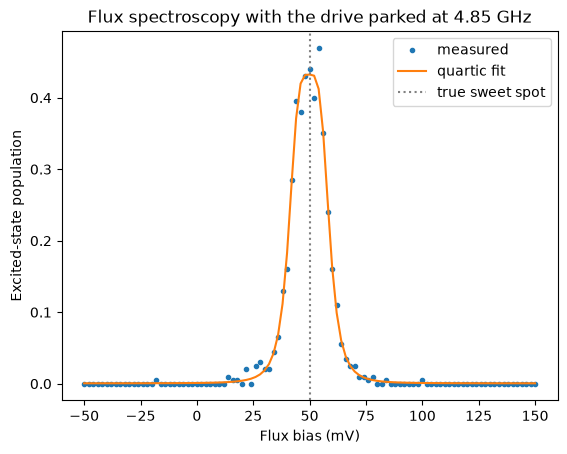

In [5]:
plt.plot(bias_v * 1e3, pop, ".", label="measured")
plt.plot(bias_v * 1e3, sweet_spot_line(bias_v, *fit), label="quartic fit")
plt.axvline(DEVICE["flux_offset"] * 1e3, color="grey", linestyle=":", label="true sweet spot")
plt.xlabel("Flux bias (mV)")
plt.ylabel("Excited-state population")
plt.title("Flux spectroscopy with the drive parked at 4.85 GHz")
plt.legend()
plt.show()

## 5.2 What a platform has to agree to

A platform declares its surface as three separate things, and the split matters because they fail
in three different ways.

| Axis | What it holds | Example |
|---|---|---|
| Capabilities | flat dotted **tokens**, flags | `op.play`, `waveform.iq_drag`, `sweep.linear` |
| Limits | numeric thresholds | `max_loop_nesting: 4`, `min_wait_duration_ns: 8` |
| Predicates | callables that walk the AST | "no arbitrary sweep at `Wait.duration`" |

Every node in the tree declares the tokens it needs through `required_capabilities()`. The set is
**instance-aware**: it depends on the node's data, not just its class. A `play` of a `Square` asks
for different tokens than a `play` of an `IQPair`, and a `play` of a string alias asks for almost
nothing, because the alias has not been resolved to a shape yet.

The token prefix says where it is checked. `op.*` and `waveform.*` go to the bus the operation
touches, or to the platform when the operation touches no bus at all. `block.*`, `sweep.*`, and
`expr.*` always go to the platform, even when they show up on an operation that does touch a bus:
the `expr.variable` on the `set_offset` below is a claim about the expression language, not about
the flux line.

In [6]:
from qprogram.operations import Play  # only to show the tokens; you never build ops by hand

for node in program.body.walk():
    print(f"{type(node).__name__:14s} {sorted(node.required_capabilities())}")

print()
# Same class, same bus, three different demands. The waveform decides two of the three tokens.
pair = IQPair(Square(0.2, 100), Square(0.0, 100))
print("Square:  ", sorted(Play(q[0].drive, Square(0.2, 100)).required_capabilities()))
print("IQPair:  ", sorted(Play(q[0].drive, pair).required_capabilities()))
print("an alias:", sorted(Play(q[0].drive, "saturation").required_capabilities()))

Block          ['block.block']
Average        ['block.average']
Sweep          ['block.sweep', 'sweep.linear', 'sweep.linspace']
SetOffset      ['expr.variable', 'op.set_offset']
SetFrequency   ['op.set_frequency']
Play           ['op.play', 'waveform.alias']
Sync           ['op.sync']
Measure        ['measure.fields.state', 'op.measure', 'waveform.alias', 'waveform.iq']

Square:   ['op.play', 'waveform.single', 'waveform.square']
IQPair:   ['op.play', 'waveform.iq', 'waveform.iq_pair']
an alias: ['op.play', 'waveform.alias']


## 5.3 Describing rack B

A `PlatformCapabilities` has three parts:

- `bus`: a profile per `(element_kind, bus_kind)` slot, so `("q", "flux")` can differ from
  `("q", "drive")`.
- `platform`: the bus-less half. Blocks, sweep shapes, and expression kinds live here.
- `default_bus_profile`: the fallback for a raw-string bus, which carries no schema metadata to
  route on, and for a schema-backed bus whose slot the platform did not list.

Each of those is a `BusCapabilities`, which splits into two halves: `rt` for what the hardware
sequencer can do in real time, and `host` for what the lab server can do one iteration at a time.
Either half may be `None`, and that is how rack B says what it is. The flux slot has **no `rt`
half at all**.

Real vendor code builds these from registered profiles (`CompilerCapabilities.from_profile(...)`).
Here we build them by hand from the live token registry, because seeing the set subtraction is the
point.

In [7]:
from qprogram.protocol import CAPABILITY_REGISTRY

everything = frozenset(CAPABILITY_REGISTRY)  # every token the installed language knows about


def profile(name, tokens, limits=None, predicates=()):
    """One half of one slot: a token set, numeric limits, and predicates."""
    return qp.CompilerCapabilities(
        profile=name, version=(0, 1, 0), capabilities=tokens,
        limits=limits or {}, predicates=predicates, vendor_versions={},
    )


param_ops = {"op.set_parameter", "op.get_parameter"}  # instrument settings, not sequencer opcodes
fast = qp.BusCapabilities(rt=profile("fast-awg", everything - param_ops),
                          host=profile("fast-awg", everything))
slow = qp.BusCapabilities(rt=None, host=profile("slow-dac", everything))  # no sequencer at all
base = qp.BusCapabilities(rt=profile("base", everything), host=profile("base", everything))

caps = qp.PlatformCapabilities(
    bus={("q", "drive"): fast, ("q", "readout"): fast, ("q", "flux"): slow},
    platform=base,
    default_bus_profile=fast,
)

print("tokens in the registry:", len(everything))
print("drive rt, op.play:         ", fast.rt.supports("op.play"))
print("drive rt, op.set_parameter:", fast.rt.supports("op.set_parameter"))
print("flux rt half:              ", slow.rt)

tokens in the registry: 67
drive rt, op.play:          True
drive rt, op.set_parameter: False
flux rt half:               None


### Validate

`qp.validate(program, caps)` returns a list of diagnostics and an execution plan. It never raises.
That separation is deliberate. Validation reports, and the caller decides. A platform's `execute()`
is the thing that turns an error into an exception.

The plan maps each operation and each block to the set of domains it may run in. The root `body` is
not an entry, because there is nowhere else for it to run. Operations come first, then the loops
that contain them. The drive and readout operations can go either way, the `set_offset` on the flux
bus is host-side only, and both loops inherit that from it.

In [8]:
diagnostics, plan = qp.validate(program, caps)

for diag in diagnostics:
    print(diag)
    print()

for node, domains in plan.items():
    print(f"{type(node).__name__:14s} {'|'.join(sorted(domains))}")

[warning] forced-host: Block 'Average' falls back to host-side execution: contains host-side-only sub-block 'Sweep'. (at body[0])

[info] reorderable-averaging: Block 'Average' runs host-side only because it encloses a host-side sweep; its measurement sequence supports real-time hardware. Moving the sweep outside the average (hoisting the host-side-only setup with it) would let the averaging run in real-time hardware — see qprogram.optimize(). (at body[0])

SetOffset      host
SetFrequency   host|rt
Play           host|rt
Sync           host|rt
Measure        host|rt
Sweep          host
Average        host


### The plan, drawn

`qp.explain` renders the same plan as a tree: each node as its `.qp` line, the domain column on the
right, and the diagnostics annotated inline (`!!` error, `~` warning, `i` info).

The `forced-host` warning is a *warning*, not an error. The program will run. It will run with the
averaging loop on the host, which means 200 network round trips per bias point instead of 200
sequencer iterations. On real hardware that is the difference between a coffee break and a lunch
break, and the validator says so out loud.

In [9]:
print(qp.explain(program, caps))

plan for 'flux_sweep' — errors: 0 · warnings: 1 · info: 1
body
└─ average 200:                                                                          [host]     ~ forced-host: contains host-side-only sub-block 'Sweep'  i reorderable-averaging: Block 'Average' runs host-side only because it encloses a host-side sweep; its measurement sequence supports real-time hardware. Moving the sweep outside the average (hoisting the host-side-only setup with it) would let the averaging run in real-time hardware — see qprogram.optimize().
   └─ for bias in Linspace(start=-0.05, stop=0.15, num=101):                             [host]
      ├─ set_offset q[0].flux bias                                                       [host]
      ├─ set_frequency q[0].drive 4850000000.0                                           [rt|host]
      ├─ play q[0].drive "saturation"                                                    [rt|host]
      ├─ sync q[0].drive q[0].readout                                        

## 5.4 `qp.optimize`: the rewrite the plan is asking for

Look at the info line in the plan. The averaging is host-side only because it *encloses* the flux
sweep, but nothing inside the averaging needs the host. Swap the two loops and the problem goes
away:

```
average 200:                          for bias in Linspace(...):     # host, one DAC write per point
  for bias in Linspace(...):            set_offset q[0].flux bias    # hoisted setup
    set_offset q[0].flux bias    -->    average 200:                 # now real-time
    play q[0].drive ...                   play q[0].drive ...
    measure q[0].readout ...              measure q[0].readout ...
```

`qp.optimize(program, caps)` applies it. It is opt-in, and the reason is honest. The rewrite is not
unconditionally equivalent. It groups all 200 shots of one bias point together instead of
interleaving passes over the sweep, identical for a stationary system and different under drift.
The hoisted `set_offset` also runs once per bias point instead of once per shot. For a DC bias that
is the whole point, and it would be wrong for an operation with side effects, so the rewrite
only ever hoists a leading run of host-side-only operations and refuses to move one past an
operation it would reorder against.

In [10]:
optimized = qp.optimize(program, caps)

print(qp.explain(optimized, caps))
print()
print("body[0] before:", type(program.body.elements[0]).__name__)
print("body[0] after: ", type(optimized.body.elements[0]).__name__)

plan for 'flux_sweep' — errors: 0 · warnings: 0 · info: 0
body
└─ for bias in Linspace(start=-0.05, stop=0.15, num=101):                                [host]
   ├─ set_offset q[0].flux bias                                                          [host]
   └─ average 200:                                                                       [rt|host]
      ├─ set_frequency q[0].drive 4850000000.0                                           [rt|host]
      ├─ play q[0].drive "saturation"                                                    [rt|host]
      ├─ sync q[0].drive q[0].readout                                                    [rt|host]
      └─ measure q[0].readout "readout" "weights" name="q0/readout/m0" fields=["state"]  [rt|host]

body[0] before: Average
body[0] after:  Sweep


### The broadcast that blocks the rewrite

`program.sync()` with no arguments means "align every bus in this program". It is a different
operation from `program.sync([q[0].drive, q[0].readout])`, even though both ask for the same token
`op.sync`. A broadcast touches every bus, so the validator intersects the domains of every bus in
the program, and the flux bus has no real-time half. The bare `sync` therefore lands on the host,
in the middle of a run of real-time operations, and the rewrite refuses to hoist across it.

The same thing that made the plan correct made the rewrite impossible. Naming the two buses you
actually want aligned costs you nothing and keeps the averaging in hardware.

In [11]:
from qprogram.operations import Sync

broadcast, _ = flux_sweep(None)  # program.sync(), no targets
b_diagnostics, b_plan = qp.validate(broadcast, caps)


def sync_domain(prog, node_plan):
    """The domain set the plan assigned to this program's one sync operation."""
    node = next(n for n in prog.body.walk() if isinstance(n, Sync))
    return "|".join(sorted(node_plan[node]))


print("sync q[0].drive q[0].readout ->", sync_domain(program, plan))
print("sync (broadcast)             ->", sync_domain(broadcast, b_plan))
print("targeted, diagnostic codes: ", [d.code for d in diagnostics])
print("broadcast, diagnostic codes:", [d.code for d in b_diagnostics])

targeted_top = type(qp.optimize(program, caps).body.elements[0]).__name__
broadcast_top = type(qp.optimize(broadcast, caps).body.elements[0]).__name__
print("targeted,  optimize gives body[0] =", targeted_top)
print("broadcast, optimize gives body[0] =", broadcast_top)

sync q[0].drive q[0].readout -> host|rt
sync (broadcast)             -> host
targeted, diagnostic codes:  ['forced-host', 'reorderable-averaging']
broadcast, diagnostic codes: ['forced-host']
targeted,  optimize gives body[0] = Sweep
broadcast, optimize gives body[0] = Average


## 5.5 Diagnostics as a contract

Three racks, three ways to say no. All three come back through the same channel: a list of
`Diagnostic` objects with a `severity`, a machine-readable `code`, a `message`, the offending
`node`, and a structural `path` you can resolve back to a line of `.qp` text.

First case: the rack does not implement the operation. Rack C has a plain DC source on the flux
line, one that takes a voltage over a serial link and has no offset register at all. Drop
`op.set_offset` from its token set and the program stops being runnable, at one exact node.

In [12]:
dc_only = qp.BusCapabilities(rt=None, host=profile("dc-source", everything - {"op.set_offset"}))
caps_dc = qp.PlatformCapabilities(
    bus={("q", "drive"): fast, ("q", "readout"): fast, ("q", "flux"): dc_only},
    platform=base,
    default_bus_profile=fast,
)

for diag in qp.validate(program, caps_dc)[0]:
    print(diag)
    print("  severity:  ", diag.severity)
    print("  code:      ", diag.code)
    print("  capability:", diag.capability)
    print("  path:      ", diag.path, "->", qp.format_path(diag.path))

[error] missing-capability: 'SetOffset' requires capability 'op.set_offset' which is not supported by 'dc-source' (host) (at body[0][0][0])
  severity:   error
  code:       missing-capability
  capability: op.set_offset
  path:       (0, 0, 0) -> body[0][0][0]


### A numeric limit

Second case: the program is expressible but too big. Sequencers have a finite number of loop
registers, and `max_loop_nesting` is the limit that catches it. Below is the Part 3 flux arc on a
smaller grid, three repetition levels deep (average, bias, frequency), against a rack whose
sequencer has two.

The `limit` field carries the pair `(name, observed)`, so a tool can report the number without
parsing the message.

In [13]:
two_loops = profile("shallow", everything, limits={"max_loop_nesting": 2})
caps_shallow = qp.PlatformCapabilities(
    bus={("q", "drive"): fast, ("q", "readout"): fast, ("q", "flux"): slow},
    platform=qp.BusCapabilities(rt=two_loops, host=two_loops),
    default_bus_profile=fast,
)

arc = qp.QProgram(label="flux_arc", schema=schema)
arc_bias = arc.variable("bias", label="Flux bias", units="V")
arc_freq = arc.variable("drive_freq", label="Drive frequency", units="Hz")
with arc.average(shots=50):
    with arc.sweep(arc_bias, qp.Linspace(-0.05, 0.15, 21)):
        arc.set_offset(q[0].flux, arc_bias)
        with arc.sweep(arc_freq, qp.Linspace(4.70e9, 4.90e9, 21)):
            arc.set_frequency(q[0].drive, arc_freq)
            arc.play(q[0].drive, "saturation")
            arc.sync([q[0].drive, q[0].readout])
            arc.measure(q[0].readout, "readout", "weights", fields=(MF.STATE,))

for diag in qp.validate(arc, caps_shallow)[0]:
    print(diag)
    print("  limit:", diag.limit)

[error] limit-exceeded: Program nests loops 3 deep; limit max_loop_nesting=2
  limit: ('max_loop_nesting', 3.0)
[warning] forced-host: Block 'Average' falls back to host-side execution: contains host-side-only sub-block 'Sweep'. (at body[0])
  limit: None


### A rule about how a value is used

Third case: the operation is supported, the limits are fine, and it still cannot run, because of
how two nodes interact. Take `wait(bus, duration)` as the canonical example. It accepts a variable,
but on many backends the wait instruction takes a fixed-step counter. A delay swept by `Range` is a
register increment. The same delay swept by `Values([0, 200, 800, 3200])` is an arbitrary list,
and there is nowhere to put it.

No flat token can express that. The answer depends on the *binding loop*, which is a different
node in the tree. This is what predicates are for. A predicate is a callable that receives each
node and a `ValidationContext` carrying the cross-node facts:

| Query | Returns |
|---|---|
| `ctx.sweep_kind_of(var)` | `"linear"`, `"arbitrary"`, or `None` when the variable is not loop-bound |
| `ctx.binding_loop_of(var)` | the block that binds the variable |
| `ctx.max_loop_nesting` | deepest repetition depth in the program |
| `ctx.measurement_count` | number of measurement operations |
| `ctx.program_buses` | every bus the program touches |

Yield a `Diagnostic` for a hard no. Yield a `DomainConstraint` instead when the answer is "not in
the sequencer, but the host can do it": the classifier subtracts that domain from the binding loop
and the program still runs. That is the second road to the `forced-host` warning from 5.3, where
the flux slot simply had no real-time half to begin with.

In [14]:
from qprogram.operations import Wait
from qprogram.variable import Variable


def reject_arbitrary_wait(node, ctx):
    """Rack D's wait instruction takes a fixed-step counter, so arbitrary delay lists are out."""
    if not isinstance(node, Wait) or not isinstance(node.duration, Variable):
        return
    if ctx.sweep_kind_of(node.duration) == "arbitrary":
        yield qp.Diagnostic(
            severity="error",
            code="rackd.arbitrary-wait-sweep",
            message=(
                f"Variable {node.duration.id!r} is swept with arbitrary values and used at "
                f"Wait.duration. Use Range or Linspace, or a constant duration."
            ),
            node=node,
        )


checked = qp.BusCapabilities(
    rt=profile("rack-d", everything - param_ops, predicates=(reject_arbitrary_wait,)),
    host=profile("rack-d", everything, predicates=(reject_arbitrary_wait,)),
)
caps_rack_d = qp.PlatformCapabilities(
    bus={("q", "drive"): checked, ("q", "readout"): checked, ("q", "flux"): slow},
    platform=base,
    default_bus_profile=checked,
)

# A predicate belongs to one half of one slot, like a token does.
print("predicates on rack D's drive bus, rt half:",
      [p.__name__ for p in caps_rack_d.for_bus(q[0].drive).rt.predicates])

predicates on rack D's drive bus, rt half: ['reject_arbitrary_wait']


In [15]:
def t1_program(source):
    """Inversion recovery, with the delay axis coming from whatever sweep source you pass."""
    prog = qp.QProgram(label="t1", schema=schema)
    delay = prog.variable("delay", label="Delay", units="ns")
    with prog.average(shots=50), prog.sweep(delay, source):
        prog.play(q[0].drive, "pi")
        prog.wait(q[0].drive, delay)
        prog.sync([q[0].drive, q[0].readout])
        prog.measure(q[0].readout, "readout", "weights", fields=(MF.STATE,))
    return prog


for source in (qp.Range(0, 20_000, 500), qp.Values([0, 200, 800, 3200, 12_800])):
    found = qp.validate(t1_program(source), caps_rack_d)[0]
    print(f"{type(source).__name__:9s} {[str(d) for d in found] or 'no diagnostics'}")

Range     no diagnostics
Values    ["[error] rackd.arbitrary-wait-sweep: Variable 'delay' is swept with arbitrary values and used at Wait.duration. Use Range or Linspace, or a constant duration. (at body[0][0][1])"]


### 🧩 Exercise 5.1: your own rule

Rack B's flux line goes through a bias tee that saturates at 0.25 V. A sweep that asks for more
than that will not blow anything up, it will silently clip, and that is worse. You get a flux arc
with a flat section and no warning.

Write a predicate that catches it. Filter for `SetOffset` nodes, find the sweep that binds the
offset value with `ctx.binding_loop_of`, read the sweep's own numbers off `loop.source.values()`,
and yield an error when the largest magnitude exceeds `SAFE_VOLTS`.

The two programs below differ only in the range they sweep. The first must pass and the second
must fire.

In [16]:
from qprogram.operations import SetOffset

SAFE_VOLTS = 0.25


def flux_within_range(node, ctx):
    """Reject a flux sweep that leaves the linear range of the bias tee."""
    if not isinstance(node, SetOffset):
        return
    value = node.offset_path0
    if isinstance(value, Variable):
        loop = ctx.binding_loop_of(value)
        reach = max(abs(v) for v in loop.source.values()) if loop is not None else 0.0
    else:
        reach = abs(value)
    if reach > SAFE_VOLTS:
        yield qp.Diagnostic(
            severity="error",
            code="rackb.flux-out-of-range",
            message=f"flux offset reaches {reach:.2f} V, past the {SAFE_VOLTS} V bias-tee limit",
            node=node,
        )


guarded_flux = qp.BusCapabilities(
    rt=None, host=profile("slow-dac", everything, predicates=(flux_within_range,))
)
caps_guarded = qp.PlatformCapabilities(
    bus={("q", "drive"): fast, ("q", "readout"): fast, ("q", "flux"): guarded_flux},
    platform=base,
    default_bus_profile=fast,
)


def bias_scan(low, high):
    """A bare flux scan over one range, for the predicate to judge."""
    prog = qp.QProgram(label="bias_scan", schema=schema)
    bias = prog.variable("bias", units="V")
    with prog.average(shots=10), prog.sweep(bias, qp.Linspace(low, high, 11)):
        prog.set_offset(q[0].flux, bias)
        prog.measure(q[0].readout, "readout", "weights", fields=(MF.STATE,))
    return prog


for low, high in ((-0.05, 0.15), (-0.40, 0.40)):
    found = qp.validate(bias_scan(low, high), caps_guarded)[0]
    errors = [str(d) for d in found if d.severity == "error"]
    print(f"{low:+.2f} V to {high:+.2f} V -> {errors or 'no errors'}")

-0.05 V to +0.15 V -> no errors
-0.40 V to +0.40 V -> ['[error] rackb.flux-out-of-range: flux offset reaches 0.40 V, past the 0.25 V bias-tee limit (at body[0][0][0])']


## 5.6 Porting: names, then numbers

Two things have to change when the program moves next door, and QProgram keeps them apart on
purpose.

**Bus references** change with `program.rebind`. It re-resolves every `BusRef` structurally through
a schema, so the result is still a typed `BusRef` with its element, index, kind, channel type, and
ADC flag intact. That is why it can move an experiment onto a different qubit, or onto a rack with
a different naming convention, and still validate. Auto-generated measurement names that embed the
bus are re-derived; names you chose yourself are left alone.

In [17]:
moved = program.rebind(elements={("q", 0): ("q", 1)})  # same rack, the other qubit
renamed = program.rebind(naming=BusNaming("{kind}_{element}{index}"))  # rack B's convention

print("original:", sorted(program.buses))
print("moved:   ", sorted(moved.buses))
print("renamed: ", sorted(renamed.buses))
print()
print(qp.dumps(renamed).split("body:")[0])  # the header carries the naming pattern
flux_line = next(line for line in qp.dumps(renamed).splitlines() if "set_offset" in line)
print("body, unchanged:", flux_line.strip())  # still a structural path, not the resolved string
print("measurement handle, original:", m0.name)
print("measurement handle, renamed: ", renamed.measurement_handles()[0].name)

original: ['q0/drive', 'q0/flux', 'q0/readout']
moved:    ['q1/drive', 'q1/flux', 'q1/readout']
renamed:  ['drive_q0', 'flux_q0', 'readout_q0']

#!QProgram 1.0

metadata:
  label: "flux_sweep"

schema:
  naming: "{kind}_{element}{index}"
  element q:
    drive info=IQ
    readout info=IQ+acquires
    flux info=single


body, unchanged: set_offset q[0].flux bias
measurement handle, original: q0/readout/m0
measurement handle, renamed:  readout_q0/m0


The `.qp` text of the renamed program still says `q[0].flux`, because the path form is structural:
the schema section carries the naming pattern, and the resolved string is derived from it. The file
is portable, and only the driver ever sees `flux_q0`.

**Waveforms** change with a `WaveformLibrary`. The string aliases in the program (`"saturation"`,
`"readout"`, `"weights"`) are the calibration seam from Part 3: the program says which pulse, the
library says what that pulse is on this chip. Resolution runs in three tiers, most specific first:

| Tier | Key | Use it for |
|---|---|---|
| exact | `(element, idx, kind, name)` | one qubit's calibrated pulse |
| family | `(element, kind, name)` | every qubit's readout tone |
| global | `(name,)` | integration weights, markers |

The library is a separate artifact with its own `.wfl` text format, and it is deliberately not
inside the `.qp` file. The program is the experiment and changes when you change the experiment.
The library is the calibration and changes every morning. Two lifetimes, two files, and the diff
of either one tells you something true.

In [18]:
library = qp.WaveformLibrary()
library.set("saturation", IQPair(Square(0.02, 20_000), Square(0.0, 20_000)),
            element="q", idx=0, kind="drive")  # exact: q0's long weak tone
library.set("readout", IQPair(Square(0.2, 2000), Square(0.0, 2000)),
            element="q", kind="readout")  # family: any qubit's readout
library.set("weights", IQPair(Square(1.0, 2000), Square(1.0, 2000)))  # global

print(library.dumps())
print("round-trips:", qp.WaveformLibrary.loads(library.dumps()).dumps() == library.dumps())

#!WaveformLibrary 1.0
"saturation" q[0].drive = IQPair(I=Square(amplitude=0.02, duration=20000), Q=Square(amplitude=0.0, duration=20000))
"readout" q[*].readout = IQPair(I=Square(amplitude=0.2, duration=2000), Q=Square(amplitude=0.0, duration=2000))
"weights" = IQPair(I=Square(amplitude=1.0, duration=2000), Q=Square(amplitude=1.0, duration=2000))

round-trips: True


`program.with_waveforms(library)` returns a copy with the aliases replaced, re-running the
channel-type check on every replacement (an IQ pair on a single-channel bus is still an error). The
same library resolves against the *renamed* program with no edits, because the tiers are keyed on
the schema coordinate and not on the bus string.

Binding is a step you take, not something `execute()` does for you. The reference platform never
looks at a pulse, so every program in this notebook ran happily with `"saturation"` left as a
string. A real platform has to turn that alias into samples before it can upload anything, which is
why the port ends with `with_waveforms` and not with a hopeful `run`.

Run the bound program and fit it, and the sweet spot comes back where rack A found it. That is the
end of the port. New bus names, pulse shapes supplied from a file, the same program, the same
answer.

In [19]:
bound = renamed.with_waveforms(library)
for line in qp.dumps(bound).splitlines():
    if "IQPair" in line:  # the two lines where an alias used to be
        print(line.strip())
print()

ported_model = qp.MockMeasurementModel(p_excited=p_flux, noise=0.02, seed=11)
ported_result = qp.simulate(bound, model=ported_model)
_, ported_pop, ported_fit = fit_sweet_spot(ported_result, bound.measurement_handles()[0])

print(f"rack A sweet spot: {fit[1] * 1e3:.2f} mV")
print(f"rack B sweet spot: {ported_fit[1] * 1e3:.2f} mV")
print(f"device truth:      {DEVICE['flux_offset'] * 1e3:.2f} mV")
print("same populations:", bool(np.allclose(pop, ported_pop)))

play q[0].drive IQPair(I=Square(amplitude=0.02, duration=20000), Q=Square(amplitude=0.0, duration=20000))
measure q[0].readout IQPair(I=Square(amplitude=0.2, duration=2000), Q=Square(amplitude=0.0, duration=2000)) IQPair(I=Square(amplitude=1.0, duration=2000), Q=Square(amplitude=1.0, duration=2000)) name="readout_q0/m0" fields=["state"]



rack A sweet spot: 49.76 mV
rack B sweet spot: 49.76 mV
device truth:      50.00 mV
same populations: True


### 🧩 Exercise 5.2: port the two-dimensional arc

The `arc` program from 5.5 has the shape of the Part 3 experiment: a slow bias loop on the outside,
a fast frequency scan inside it. Take it to rack B:

1. Rebind it to the `drive_q0` naming convention with `BusNaming("{kind}_{element}{index}")`.
2. Print the bus strings before and after, to prove the names changed.
3. Validate the ported program against `caps` and compare the diagnostic codes to the original's.

The point is the third step. Renaming buses must not change what a rack thinks of the program,
because the validator routes on the schema coordinate, not on the string.

In [20]:
ported_arc = arc.rebind(naming=BusNaming("{kind}_{element}{index}"))

print("before:", sorted(arc.buses))
print("after: ", sorted(ported_arc.buses))
print()
print("original codes:", [d.code for d in qp.validate(arc, caps)[0]])
print("ported codes:  ", [d.code for d in qp.validate(ported_arc, caps)[0]])
print()
print(qp.explain(ported_arc, caps))

before: ['q0/drive', 'q0/flux', 'q0/readout']
after:  ['drive_q0', 'flux_q0', 'readout_q0']

original codes: ['forced-host']
ported codes:   ['forced-host']

plan for 'flux_arc' — errors: 0 · warnings: 1 · info: 0
body
└─ average 50:                                                                              [host]     ~ forced-host: contains host-side-only sub-block 'Sweep'
   └─ for bias in Linspace(start=-0.05, stop=0.15, num=21):                                 [host]
      ├─ set_offset q[0].flux bias                                                          [host]
      └─ for drive_freq in Linspace(start=4700000000.0, stop=4900000000.0, num=21):         [rt|host]
         ├─ set_frequency q[0].drive drive_freq                                             [rt|host]
         ├─ play q[0].drive "saturation"                                                    [rt|host]
         ├─ sync q[0].drive q[0].readout                                                    [rt|host]
         └─ mea

## Recap and what is next

- A platform declares three separate things: **tokens** for what it implements, **limits** for how
  much of it, and **predicates** for rules that depend on how a value is used. Each token is
  checked against the slot it belongs to (one bus, or the platform), and every slot splits into a
  real-time half and a host half.
- `qp.validate` never raises. It returns diagnostics and an `ExecutionPlan`, and the caller decides
  what an error means. `qp.explain` draws the same plan as a tree with the domain of every node.
- The DSL has no syntax for "hardware loop" and "software loop", because that is the rack's
  decision, not the experiment's. The `forced-host` warning is where the rack tells you what it
  decided.
- `qp.optimize` applies the rewrite the plan suggests. A bare `program.sync()` broadcasts across
  every bus, which drags the operation host-side and blocks the rewrite. Name the buses you mean.
- Porting splits in two: `rebind` moves bus references structurally, `WaveformLibrary` supplies the
  numbers per bus. The program stays the same file, and the calibration lives in its own `.wfl`.

Part 6 goes the other way. Instead of asking what a platform supports, you add to the language:
your own waveform, your own sweep source, and a vendor namespace with its own operation and its own
capability token, all registered from a notebook cell.